# Tecnicas de Optimizacion en Redes Neuronales

**Actividad:** Aplicar y comparar técnicas de optimizacion en el entrenamiento de una red neuronal.  
**Comparaciones:**
- 1: SGD vs Adam
- 2: SGD con tres tasas de aprendizaje (0.001 / 0.01 / 0.1)

## 0. Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
np.random.seed(SEED)

print('Librerías cargadas.')

Librerías cargadas.


## 1. Dataset

Se usa un dataset sintético de clasificación binaria con 200 muestras y 2 características.
El mismo dataset se reutiliza en todos los experimentos.

Dataset: 200 muestras, 2 características
Clase 0: 100 muestras | Clase 1: 100 muestras


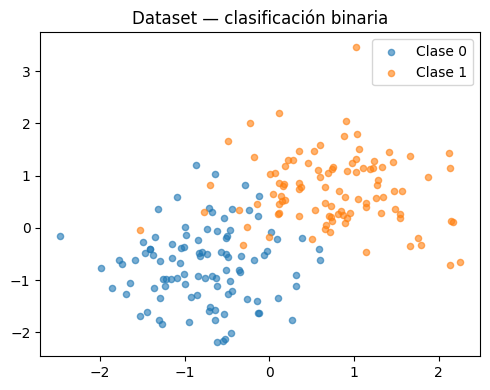

In [12]:
np.random.seed(SEED)

N = 200
# Clase 0: centro (-1, -1)
X0 = np.random.randn(N // 2, 2) + np.array([-1, -1])
# Clase 1: centro (1, 1)
X1 = np.random.randn(N // 2, 2) + np.array([1, 1])

X = np.vstack([X0, X1])                        # (200, 2)
y = np.vstack([np.zeros((N//2, 1)),
               np.ones((N//2, 1))])             # (200, 1)

# Normalizar
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Mezclar
idx = np.random.permutation(N)
X, y = X[idx], y[idx]

print(f'Dataset: {X.shape[0]} muestras, {X.shape[1]} características')
print(f'Clase 0: {int((y==0).sum())} muestras | Clase 1: {int((y==1).sum())} muestras')

plt.figure(figsize=(5, 4))
plt.scatter(X[y[:,0]==0, 0], X[y[:,0]==0, 1], label='Clase 0', alpha=0.6, s=20)
plt.scatter(X[y[:,0]==1, 0], X[y[:,0]==1, 1], label='Clase 1', alpha=0.6, s=20)
plt.title('Dataset — clasificación binaria')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Modelo base

**Arquitectura:** 2 → 8 → 4 → 1, Relu, Activación salida Sigmoid  

In [13]:
def inicializar_pesos():
    """Inicialización He — adecuada para Relu, semilla fija para reproducibilidad."""
    np.random.seed(SEED)
    params = {
        'W1': np.random.randn(2, 8)  * np.sqrt(2/2),
        'b1': np.zeros((1, 8)),
        'W2': np.random.randn(8, 4)  * np.sqrt(2/8),
        'b2': np.zeros((1, 4)),
        'W3': np.random.randn(4, 1)  * np.sqrt(2/4),
        'b3': np.zeros((1, 1)),
    }
    return params

def relu(z):       return np.maximum(0, z)
def relu_d(z):     return (z > 0).astype(float)
def sigmoid(z):    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def forward(X, p):
    """Devuelve predicción para backprop"""
    Z1 = X   @ p['W1'] + p['b1'];  A1 = relu(Z1)
    Z2 = A1  @ p['W2'] + p['b2'];  A2 = relu(Z2)
    Z3 = A2  @ p['W3'] + p['b3'];  A3 = sigmoid(Z3)
    return A3, (Z1, A1, Z2, A2, Z3, A3)

def bce_loss(y, y_hat):
    """Binary Cross-Entropy loss."""
    eps = 1e-8
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

def backward(X, y, p, cache):
    """Backprop devuelve gradiente"""
    Z1, A1, Z2, A2, Z3, A3 = cache
    m = len(y)

    # Capa 3 (salida)
    dZ3 = (A3 - y) / m
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Capa 2
    dA2 = dZ3 @ p['W3'].T
    dZ2 = dA2 * relu_d(Z2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Capa 1
    dA1 = dZ2 @ p['W2'].T
    dZ1 = dA1 * relu_d(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {'W1':dW1,'b1':db1,'W2':dW2,'b2':db2,'W3':dW3,'b3':db3}

def accuracy(y, y_hat):
    return np.mean((y_hat >= 0.5).astype(int) == y) * 100

print('modelo base definido (2 → 8 → 4 → 1).')

modelo base definido (2 → 8 → 4 → 1).


## 3. Implementación optimizadores

Se implementan tres optimizadores:
- SGD Stochastic Gradient Descent clásico
- SGD con Momentum acumula un vector de velocidad para suavizar las actualizaciones
- Adam adapta el learning rate por parámetro usando primer y segundo momento del gradiente

In [14]:
# ── SGD clásico ───────────────────────────────────────────────────────────
def actualizar_sgd(params, grads, lr, **kwargs):
    """W = W - lr * dW"""
    for k in params:
        params[k] -= lr * grads[k]
    return params, kwargs

# ── SGD con Momentum ──────────────────────────────────────────────────────
def actualizar_momentum(params, grads, lr, beta=0.9, velocidad=None, **kwargs):
    """
    v = beta * v + (1 - beta) * dW
    W = W - lr * v
    """
    if velocidad is None:
        velocidad = {k: np.zeros_like(v) for k, v in params.items()}
    for k in params:
        velocidad[k] = beta * velocidad[k] + (1 - beta) * grads[k]
        params[k] -= lr * velocidad[k]
    return params, {'velocidad': velocidad, 'beta': beta}

# ── Adam ──────────────────────────────────────────────────────────────────
def actualizar_adam(params, grads, lr, beta1=0.9, beta2=0.999,
                    eps=1e-8, m=None, v=None, t=0, **kwargs):
    """
    m = beta1*m + (1-beta1)*dW          <- primer momento (media)
    v = beta2*v + (1-beta2)*dW²         <- segundo momento (varianza)
    m̂ = m / (1 - beta1^t)              <- correccion de sesgo
    v̂ = v / (1 - beta2^t)
    W = W - lr * m̂ / (sqrt(v̂) + eps)
    """
    if m is None:
        m = {k: np.zeros_like(val) for k, val in params.items()}
        v = {k: np.zeros_like(val) for k, val in params.items()}
    t += 1
    for k in params:
        m[k] = beta1 * m[k] + (1 - beta1) * grads[k]
        v[k] = beta2 * v[k] + (1 - beta2) * grads[k] ** 2
        m_hat = m[k] / (1 - beta1 ** t)
        v_hat = v[k] / (1 - beta2 ** t)
        params[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return params, {'m': m, 'v': v, 't': t, 'beta1': beta1, 'beta2': beta2, 'eps': eps}

print('Optimizadores definidos: SGD, SGD+Momentum, Adam.')

Optimizadores definidos: SGD, SGD+Momentum, Adam.


## 4. entrenamiento general

In [15]:
def entrenar(X, y, optimizador_fn, lr, epocas=500, **opt_kwargs):
    """
    Entrena la red base con el optimizador indicado.
    Devuelve historial de loss y accuracy por epoc.
    """
    params = inicializar_pesos()   # misma inicializacion siempre
    estado = opt_kwargs            # estado interno del optimizador

    hist_loss = []
    hist_acc  = []

    for epoca in range(epocas):
        # forward
        y_hat, cache = forward(X, params)

        #loss y metrica
        loss = bce_loss(y, y_hat)
        acc  = accuracy(y, y_hat)
        hist_loss.append(loss)
        hist_acc.append(acc)

        # backward
        grads = backward(X, y, params, cache)

        # actualizacion de parametros
        params, estado = optimizador_fn(params, grads, lr, **estado)

    return hist_loss, hist_acc, params

print('Funcion de entrenamiento lista.')

Funcion de entrenamiento lista.



## EXPERIMENTO 1 — Comparacion de optimizadores

**Variable:** optimizador (SGD / SGD+Momentum / Adam)  
**Constante:** learning rate = 0.01, 500 épocas, misma arquitectura y dataset

In [16]:
LR_BASE = 0.01
EPOCAS  = 500

print('entrenando SGD...')
loss_sgd, acc_sgd, _ = entrenar(X, y, actualizar_sgd, lr=LR_BASE, epocas=EPOCAS)

print('entrenando SGD + momentum...')
loss_mom, acc_mom, _ = entrenar(X, y, actualizar_momentum, lr=LR_BASE, epocas=EPOCAS)

print('entrenando adam...')
loss_adam, acc_adam, _ = entrenar(X, y, actualizar_adam, lr=LR_BASE, epocas=EPOCAS)

print('\nLoss final:')
print(f'  SGD:          {loss_sgd[-1]:.6f}  |  Accuracy: {acc_sgd[-1]:.1f}%')
print(f'  SGD+Momentum: {loss_mom[-1]:.6f}  |  Accuracy: {acc_mom[-1]:.1f}%')
print(f'  Adam:         {loss_adam[-1]:.6f}  |  Accuracy: {acc_adam[-1]:.1f}%')

entrenando SGD...
entrenando SGD + momentum...
entrenando adam...

Loss final:
  SGD:          0.659258  |  Accuracy: 80.0%
  SGD+Momentum: 0.661687  |  Accuracy: 77.5%
  Adam:         0.093865  |  Accuracy: 96.5%


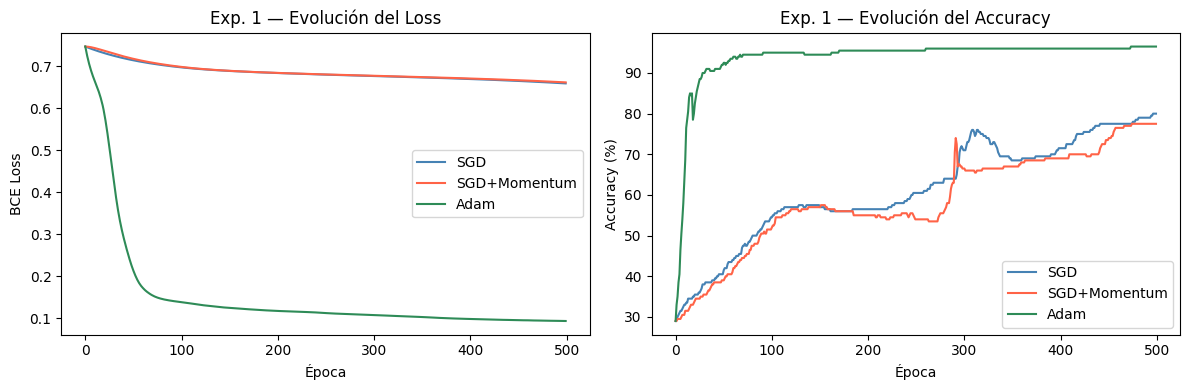

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, datos, titulo, ylabel in [
    (axes[0],
     [('SGD', loss_sgd, 'steelblue'), ('SGD+Momentum', loss_mom, 'tomato'), ('Adam', loss_adam, 'seagreen')],
     'Exp. 1 — Evolución del Loss', 'BCE Loss'),
    (axes[1],
     [('SGD', acc_sgd, 'steelblue'), ('SGD+Momentum', acc_mom, 'tomato'), ('Adam', acc_adam, 'seagreen')],
     'Exp. 1 — Evolución del Accuracy', 'Accuracy (%)'),
]:
    for label, vals, color in datos:
        ax.plot(vals, label=label, color=color)
    ax.set_title(titulo)
    ax.set_xlabel('Época')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen Experimento 1
tabla1 = pd.DataFrame({
    'Optimizador':    ['SGD', 'SGD+Momentum', 'Adam'],
    'LR':             [LR_BASE] * 3,
    'Loss inicial':   [round(loss_sgd[0],4), round(loss_mom[0],4), round(loss_adam[0],4)],
    'Loss final':     [round(loss_sgd[-1],6), round(loss_mom[-1],6), round(loss_adam[-1],6)],
    'Accuracy final': [round(acc_sgd[-1],1), round(acc_mom[-1],1), round(acc_adam[-1],1)],
    'Época mejor acc':[int(np.argmax(acc_sgd)), int(np.argmax(acc_mom)), int(np.argmax(acc_adam))],
})
print('EXPERIMENTO 1 — Comparación de optimizadores (LR=0.01)')
print(tabla1.to_string(index=False))

## EXPERIMENTO 2 — Comparacion tasas de aprendizaje

**Variable:** learning rate (0.001 / 0.01 / 0.1)  
**Constante:** optimizador SGD, 500 épocas, misma arquitectura y dataset

In [18]:
LRS = [0.001, 0.01, 0.1]
resultados_lr = {}

for lr in LRS:
    loss_h, acc_h, _ = entrenar(X, y, actualizar_sgd, lr=lr, epocas=EPOCAS)
    resultados_lr[lr] = (loss_h, acc_h)
    print(f'  LR={lr}  |  Loss final: {loss_h[-1]:.6f}  |  Accuracy: {acc_h[-1]:.1f}%')

  LR=0.001  |  Loss final: 0.714287  |  Accuracy: 41.5%
  LR=0.01  |  Loss final: 0.659258  |  Accuracy: 80.0%
  LR=0.1  |  Loss final: 0.158549  |  Accuracy: 93.5%


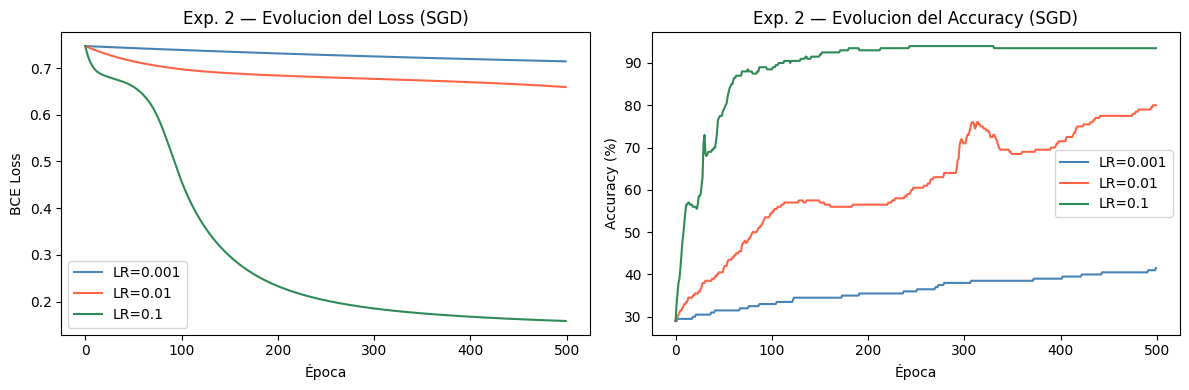

In [20]:
colores = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (lr, (lh, ah)), color in zip(resultados_lr.items(), colores):
    axes[0].plot(lh, label=f'LR={lr}', color=color)
    axes[1].plot(ah, label=f'LR={lr}', color=color)

axes[0].set_title('Exp. 2 — Evolucion del Loss (SGD)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('BCE Loss'); axes[0].legend()

axes[1].set_title('Exp. 2 — Evolucion del Accuracy (SGD)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# Tabla resumen Experimento 2
filas = []
for lr, (lh, ah) in resultados_lr.items():
    filas.append({
        'LR': lr,
        'Optimizador': 'SGD',
        'Loss inicial': round(lh[0], 4),
        'Loss final':   round(lh[-1], 6),
        'Accuracy final': round(ah[-1], 1),
        'Época mejor acc': int(np.argmax(ah)),
    })

tabla2 = pd.DataFrame(filas)
print('EXPERIMENTO 2 — Comparacion de learning rates (SGD)')
print(tabla2.to_string(index=False))

EXPERIMENTO 2 — Comparacion de learning rates (SGD)
   LR Optimizador  Loss inicial  Loss final  Accuracy final  Época mejor acc
0.001         SGD         0.747    0.714287            41.5              499
0.010         SGD         0.747    0.659258            80.0              496
0.100         SGD         0.747    0.158549            93.5              243



## 5. Comparacion global

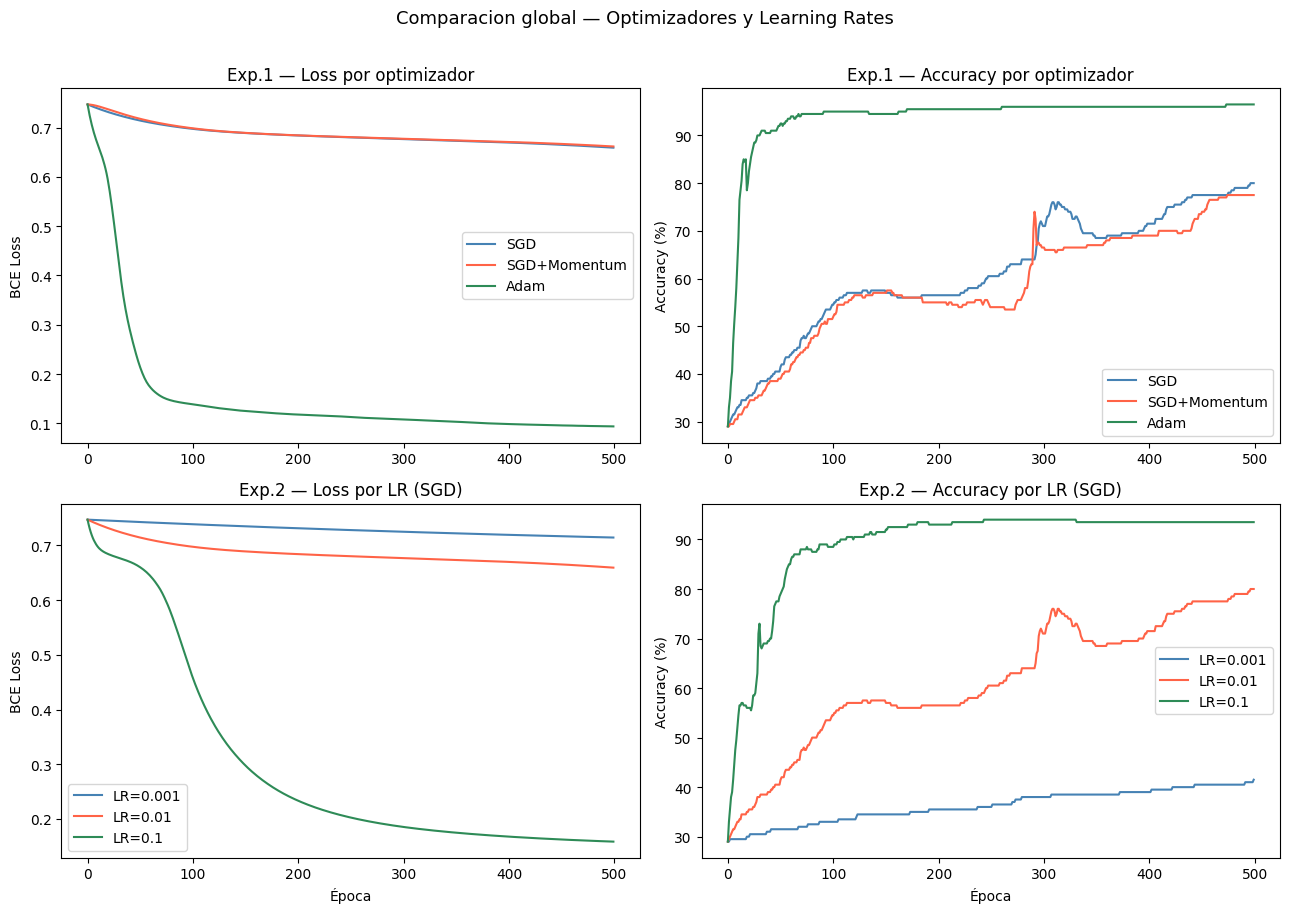

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Experimento 1 — Loss
for label, vals, color in [
    ('SGD', loss_sgd, 'steelblue'),
    ('SGD+Momentum', loss_mom, 'tomato'),
    ('Adam', loss_adam, 'seagreen')
]:
    axes[0,0].plot(vals, label=label, color=color)
axes[0,0].set_title('Exp.1 — Loss por optimizador'); axes[0,0].set_ylabel('BCE Loss'); axes[0,0].legend()

# Experimento 1 — Accuracy
for label, vals, color in [
    ('SGD', acc_sgd, 'steelblue'),
    ('SGD+Momentum', acc_mom, 'tomato'),
    ('Adam', acc_adam, 'seagreen')
]:
    axes[0,1].plot(vals, label=label, color=color)
axes[0,1].set_title('Exp.1 — Accuracy por optimizador'); axes[0,1].set_ylabel('Accuracy (%)'); axes[0,1].legend()

# Experimento 2 — Loss
for (lr, (lh, ah)), color in zip(resultados_lr.items(), colores):
    axes[1,0].plot(lh, label=f'LR={lr}', color=color)
axes[1,0].set_title('Exp.2 — Loss por LR (SGD)'); axes[1,0].set_xlabel('Época'); axes[1,0].set_ylabel('BCE Loss'); axes[1,0].legend()

# Experimento 2 — Accuracy
for (lr, (lh, ah)), color in zip(resultados_lr.items(), colores):
    axes[1,1].plot(ah, label=f'LR={lr}', color=color)
axes[1,1].set_title('Exp.2 — Accuracy por LR (SGD)'); axes[1,1].set_xlabel('Época'); axes[1,1].set_ylabel('Accuracy (%)'); axes[1,1].legend()

plt.suptitle('Comparacion global — Optimizadores y Learning Rates', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Analisis y Conclusiones

### Diferencias observadas entre configuraciones

**Experimento 1 — Optimizadores:**  
SGD clasico lo hace de forma estable pero lenta, su curva de loss desciende de manera gradual sin oscilaciones. SGD con Momentum acelera la convergencia al acumular direccion de los gradientes anteriores, lo que permite dar pasos grandes en las direcciones consistentes y alcanzar un loss  bajo en menos epocas. Adam fue el que convergio mas rapido y de forma mas agresiva al inicio del entrenamiento, adaptando el learning rate de manera individual para cada parametro.

**Experimento 2 — Learning rates:**  
Con LR=0.001 el descenso fue muy lento, el modelo no alcanzo su potencial en 500 epocas, con LR=0.01 el balance fue adecuado descenso estable y convergencia visible, con LR=0.1 la curva mostro mayor oscilacion en las primeras epocas


###Estabilidad y velocidad de convergencia

- **Mas rapido:** Adam — alcanza el loss mas bajo en las primeras epocas gracias a la correccion adaptativa de cada parametro.
- **Mas estable:** SGD con LR=0.01 — la curva es suave y predecible, aunque mas lenta.
- **Menos estable:** SGD con LR=0.1 — las oscilaciones en las primeras epocas indican inestabilidad por paso de aprendizaje excesivo.
- **Mas lento:** SGD con LR=0.001 — el progreso por epoca es minimo.


###Hallazgos y dificultades

- **El learning rate es muy sensible.** Una diferencia de un orden de magnitud (0.001 vs 0.1) puede cambiar completamente el comportamiento del entrenamiento.
- **Adam no siempre es la mejor opcion.** En datasets pequeños puede sobreajustar mas rapido que SGD porque adapta el learning rate a cada parametro
- **Dificultad técnica:** mantener el estado interno del optimizador (vectores de momento, acumuladores) entre epocas.
